# Обучение нейросетей: Базовые приемы

In [1]:
#!unzip -qo dataset.zip

In [2]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
import torch
import torch.nn.functional as F
from torch import nn
from tqdm import tqdm

# Increase these if figures appear small
plt.rcParams["figure.figsize"] = fx, fy = (14.08, 6.40)

In [3]:
def show_images(images, titles=[]):
    num = len(images)
    fig, axs = plt.subplots(nrows=1, ncols=num, squeeze=True, layout="constrained")
    axs = [axs] if num <= 1 else axs
    for i in range(num):
        ax = axs[i]
        ax.imshow(images[i])
        ax.axis("off")
        if titles != []:
            ax.set_title(titles[i])

    plt.show(fig)
    plt.close(fig)

## Обучение простого классификатора на PyTorch

In [4]:
CLASSES = {"cloudy": 0, "foggy": 1, "rainy": 2, "shine": 3, "sunrise": 4}

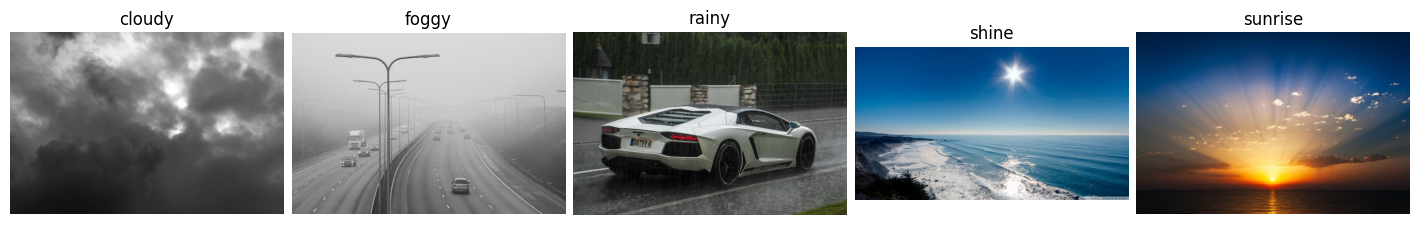

In [5]:
weather_images = []
titles = []
for weather in CLASSES.keys():
    sample = sorted(glob.glob(f"./dataset/{weather}/*")).pop(0)
    weather_images.append(PIL.Image.open(sample))
    titles.append(weather)
show_images(weather_images, titles)

Научимся использовать свои данные при обучении, для этого необхимо создать свой собственный подкласс **`torch.utils.data.Dataset`**.

Также для подтверждения успешности обучения модели понадобится валидационная выборка, которая не должна пересекаться с обучающей.

In [6]:
NETWORK_SIZE = (64, 64)
BATCH_SIZE = 16

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using the GPU 😊")
elif torch.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using MPS")
else:
    DEVICE = torch.device("cpu")
    print("Using the CPU 😞")

Using the CPU 😞


In [7]:
import torchvision.transforms.v2 as T

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
DEFAULT_TRANSFORM = T.Compose(
    [
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Resize(size=NETWORK_SIZE),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

In [8]:
import random

from torch.utils import data


class MyCustomDataset(data.Dataset):
    def __init__(
        self,
        mode,
        root_dir="./dataset",
        train_fraction=0.8,
        split_seed=42,
        transform=None,
    ):
        # We can't store all the images in memory at the same time,
        # because sometimes we have to work with very large datasets
        # so we will only store data paths.

        paths = []
        labels = []
        rng = random.Random(split_seed)
        for cls_name, cls_idx in CLASSES.items():

            # Make sure that train and validation splits
            # use the same (random) order of samples
            cls_paths = sorted(glob.glob(f"{root_dir}/{cls_name}/*"))
            split = int(train_fraction * len(cls_paths))
            rng.shuffle(cls_paths)

            if mode == "train":
                cls_paths = cls_paths[:split]
            elif mode == "valid":
                cls_paths = cls_paths[split:]
            else:
                raise RuntimeError(f"Invalid mode: {mode!r}")

            paths.extend(cls_paths)
            labels.extend(cls_idx for _ in range(len(cls_paths)))

        self._len = len(paths)
        self._paths = paths
        self._labels = np.array(labels)
        assert self._labels.shape == (self._len,)

        if transform is None:
            transform = DEFAULT_TRANSFORM
        self._transform = transform

    def __len__(self):
        return len(self._paths)

    def __getitem__(self, index):
        img_path = self._paths[index]
        label = self._labels[index]

        # Read the image from disk
        image = np.array(PIL.Image.open(img_path).convert("RGB"))

        # Apply the desired transformations
        image = self._transform(image)

        return image, label

In [9]:
import os
# use num_workers=os.cpu_count() if available
# Prepare the data
ds_train = MyCustomDataset(mode="train")
ds_valid = MyCustomDataset(mode="valid")

dl_train = data.DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)
dl_valid = data.DataLoader(
    ds_valid,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

Будем использовать простую сверточную архитектуру

In [10]:
class MyModel(nn.Sequential):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(6, 16, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(16, 5, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        # (N, 5, 7, 7) -> (N, 5 * 7 * 7 == 245)
        self.flatten = nn.Flatten(start_dim=1, end_dim=-1)

        self.fc1 = nn.Linear(5 * 7 * 7, 120)
        self.relu4 = nn.ReLU()

        self.fc2 = nn.Linear(120, 84)
        self.relu5 = nn.ReLU()

        self.fc3 = nn.Linear(84, num_classes)

## Обучение на PyTorch

In [11]:
def train(num_epochs):
    # Prepare model and optimization stuff
    model = MyModel(num_classes=len(CLASSES)).to(DEVICE)
    loss_fn = torch.nn.CrossEntropyLoss().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # The main loop
    for e in range(num_epochs):

        # Train for a single epoch
        model = model.train()
        train_loss = []
        progress_train = tqdm(
            total=len(dl_train),
            desc=f"Epoch {e}",
            leave=False,
        )
        for x_batch, y_batch in dl_train:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            p_batch = model(x_batch)
            loss = loss_fn(p_batch, y_batch)
            train_loss.append(loss.detach())

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            progress_train.update()
        progress_train.close()

        train_loss = torch.stack(train_loss).mean()
        print(
            f"Epoch {e},",
            f"train_loss: {train_loss.item():.8f}",
        )

        # Measure metrics on validation
        model = model.eval()
        valid_accs = []
        progress_valid = tqdm(
            total=len(dl_valid),
            desc=f"Epoch {e}",
            leave=False,
        )
        for x_batch, y_batch in dl_valid:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            with torch.no_grad():
                p_batch = model(x_batch)

            matches = p_batch.argmax(axis=-1) == y_batch
            valid_accs.append(matches)

            progress_valid.update()
        progress_valid.close()

        valid_accs = torch.concat(valid_accs).float().mean()
        print(
            f"Epoch {e},",
            f"valid_accs: {valid_accs.item():.8f}",
        )

    return model

## Learning

In [12]:
model = train(num_epochs=3)

Epoch 0, train_loss: 1.20652556


Epoch 0, valid_accs: 0.63000000


Epoch 1, train_loss: 0.90224856


Epoch 1, valid_accs: 0.68000001


Epoch 2, train_loss: 0.80345827


Epoch 2, valid_accs: 0.69666666


Сохранение и загрузка параметров

In [13]:
# Get all of the current model parameters
sd = model.state_dict()
print(list(sd.keys()))
print()
print("conv1.bias =", sd["conv1.bias"])

['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias', 'conv3.weight', 'conv3.bias', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']

conv1.bias = tensor([-0.0650,  0.0783, -0.0882,  0.1368,  0.0132, -0.1075])


In [14]:
# Save the parameters to disk
torch.save(sd, "model.pt")

In [15]:
# Re-create the model object from scratch
model = MyModel(num_classes=len(CLASSES))

# Load the saved parameters
#
# WARNING!
# By default, torch.load uses pickle which
# can cause arbitrary code execution.
#
# NEVER use torch.load without explicitly setting
# weights_only=True. Alternatively, consider using
# safetensors when loading parameters from
# unknown/untrusted sources.
sd = torch.load(
    "model.pt",
    map_location=DEVICE,
    weights_only=True,
)
model.load_state_dict(sd)

<All keys matched successfully>

In [16]:
CLASSES_LIST = ["cloudy", "foggy", "rainy", "shine", "sunrise"]

image = PIL.Image.open("./dataset/alien_test/shine_2.jpg").convert('RGB')
transform = DEFAULT_TRANSFORM

outputs = model(transform(image).unsqueeze(0).to(DEVICE))
probabilities = torch.softmax(outputs, dim=1)
predicted_class = torch.argmax(probabilities, dim=1)

predicted_idx = predicted_class.item()
print(f"Предсказанный класс: {CLASSES_LIST[predicted_idx]}")
print(f"Уверенность в предсказ: {probabilities[0][predicted_idx].item():.4f}")

print("\nВероятности по всем классам:")
for i, class_name in enumerate(CLASSES_LIST):
    print(f"\t{class_name}: {probabilities[0][i].item():.4f}")

Предсказанный класс: shine
Уверенность в предсказ: 0.7504

Вероятности по всем классам:
	cloudy: 0.1795
	foggy: 0.0227
	rainy: 0.0429
	shine: 0.7504
	sunrise: 0.0044


---

## PyTorch Lightning

<img src="https://code.mipt.ru/courses-public/cv/storage/-/raw/seminars/nn-training-basics/lightning_logo.png" width="50%">

### Почему PyTorch Lightning?

#### Много реализованного функционала

* Обучение на GPU/нескольких GPU/TPU 

* Multi-node training

* Авто логгирование

* Gradient accumulation

* …

#### Меньше boilerplate кода

Любое исследование можно начать с простого кода и быстро добавить более сложные (уже реализованные) вещи, такие как: обучение на GPU, 16-bit, сохрание чекпоинтов, логгирование, …

PyTorch Lightning сделал и протестировал много всего за Вас, чтобы Вы могли сосредоточиться на исследовании других идей.

Меньше инженерного кода означает:

* меньше багов

* более быстрое итерирование и прототипирование

#### Стандартная структура кода

PyTorch Lightning задает дефолтную "opinionated" схему организации кода. Переходя в новый проект не нужно с нуля разбираться в том, как авторы переизобрели велосипед. Callback функции имеют предсказуемые имена, меньше глобальных объектов, меньше магических констант и тп.

In [17]:
import lightning as L


# Direct translation of the previous train function
class MyTrainingModule(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = MyModel(num_classes=len(CLASSES))
        self.train_loss = []
        self.valid_accs = []

    def configure_optimizers(self):
        return torch.optim.Adam(self.model.parameters(), lr=1e-3)

    def training_step(self, batch):
        x, y = batch
        p = self.model(x)
        loss = F.cross_entropy(p, y)
        self.train_loss.append(loss.detach())
        return loss

    def validation_step(self, batch):
        x, y = batch
        p = self.model(x)
        matches = p.argmax(axis=-1) == y
        self.valid_accs.append(matches)
        return {}

    def on_train_epoch_end(self):
        epoch_loss = torch.stack(self.train_loss).mean()
        print(
            f"Epoch {self.trainer.current_epoch},",
            f"train_loss: {epoch_loss.item():.8f}",
        )
        # don't forget to clear the saved losses
        self.train_loss.clear()

    def on_validation_epoch_end(self):
        epoch_accs = torch.concat(self.valid_accs).float().mean()
        print(
            f"Epoch {self.trainer.current_epoch},",
            f"valid_accs: {epoch_accs.item():.8f}",
        )
        # don't forget to clear the saved accuracies
        self.valid_accs.clear()

In [18]:
# Init our training module
training_module = MyTrainingModule()

# Initialize a trainer
trainer = L.Trainer(accelerator="auto", max_epochs=3)

# Train the model ⚡
trainer.fit(training_module, dl_train, dl_valid)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ MyModel │ 42.2 K │ train │     0 │
└───┴───────┴─────────┴────────┴───────┴───────┘

Trainable params: 42.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 42.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\coding\falt_lessons\MIPT_ML_CV\_venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:43
4: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

...

Epoch 1, valid_accs: 0.68333334

Epoch 1, train_loss: 0.93033892

Epoch 2, valid_accs: 0.69333333

Epoch 2, train_loss: 0.82768267

`Trainer.fit` stopped: `max_epochs=3` reached.


### Возобновление обучения

Как уже было сказано выше в Pytorch Lightning реализовано автоматическое логгирование.

Сохранены все запуски: 

In [19]:
#!tree lightning_logs/
!ls -R lightning_logs/

lightning_logs/:
version_0
version_1
version_10
version_2
version_3
version_4
version_5
version_6
version_7
version_8
version_9

lightning_logs/version_0:
checkpoints
events.out.tfevents.1773411597.FERRUM-PC.23356.0
hparams.yaml

lightning_logs/version_0/checkpoints:
epoch=2-step=225.ckpt

lightning_logs/version_1:
checkpoints
events.out.tfevents.1773411686.FERRUM-PC.23356.1
hparams.yaml

lightning_logs/version_1/checkpoints:
epoch=4-step=375.ckpt

lightning_logs/version_10:
checkpoints
events.out.tfevents.1774015509.FERRUM-PC.38852.0
hparams.yaml

lightning_logs/version_10/checkpoints:
epoch=2-step=225.ckpt

lightning_logs/version_2:
checkpoints
events.out.tfevents.1773411775.FERRUM-PC.23356.2
hparams.yaml

lightning_logs/version_2/checkpoints:
epoch=2-step=225.ckpt

lightning_logs/version_3:
checkpoints
events.out.tfevents.1773411866.FERRUM-PC.23356.3
hparams.yaml

lightning_logs/version_3/checkpoints:
epoch=9-step=750.ckpt

lightning_logs/version_4:
checkpoints
events.out.tfevents.1

Как видите, Lightning автоматически сохранил чекпоинт последней эпохи. Если прервать обучение, то все равно будет сохранены результаты с последней успешно завершившейся эпохи.

Обратите внимание, что чекпоинт - это не просто веса обученной модели. Например, в чекпоинт также включаются статистики оптимизатора. Таким образом, используя чекпоинт можно возобновить прерванный процесс обучения.

In [20]:
last_ckpt = "lightning_logs/version_0/checkpoints/epoch=2-step=225.ckpt"
ckpt = torch.load(last_ckpt, weights_only=True, map_location=DEVICE)
print(list(ckpt.keys()))

['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers']


In [21]:
# Continue training the model for 2 more epochs
training_module = MyTrainingModule()
trainer = L.Trainer(accelerator="auto", max_epochs=5)
trainer.fit(training_module, dl_train, dl_valid, ckpt_path=last_ckpt)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Restoring states from the checkpoint path at lightning_logs/version_0/checkpoints/epoch=2-step=225.ckpt
c:\coding\falt_lessons\MIPT_ML_CV\_venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:566: The dirpath has changed from 'c:\\coding\\falt_lessons\\MIPT_ML_CV\\04-sem-CNN\\lightning_logs\\version_0\\checkpoints' to 'c:\\coding\\falt_lessons\\MIPT_ML_CV\\04-sem-CNN\\lightning_logs\\version_11\\checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.


┏━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ MyModel │ 42.2 K │ train │     0 │
└───┴───────┴─────────┴────────┴───────┴───────┘

Trainable params: 42.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 42.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Restored all states from the checkpoint at lightning_logs/version_0/checkpoints/epoch=2-step=225.ckpt


Output()

...

Epoch 3, valid_accs: 0.67000002

Epoch 3, train_loss: 0.75016373

Epoch 4, valid_accs: 0.67333335

Epoch 4, train_loss: 0.68768883

`Trainer.fit` stopped: `max_epochs=5` reached.


### Tensorboard

Инструментарий визуализации от TensorFlow встроенный создателями Pytorch Lightning

In [35]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [36]:
%tensorboard --logdir lightning_logs

Reusing TensorBoard on port 6006 (pid 32460), started 6 days, 23:48:58 ago. (Use '!kill 32460' to kill it.)

### Подсчет метрик

In [37]:
import torchmetrics


class MyTrainingModule(L.LightningModule):
    def __init__(self, num_classes=len(CLASSES)):
        super().__init__()
        self.model = MyModel(num_classes=num_classes)
        self.accuracy = torchmetrics.classification.Accuracy(
            task="multiclass",
            num_classes=num_classes,
        )

    def configure_optimizers(self):
        return torch.optim.Adam(self.model.parameters(), lr=1e-3)

    def training_step(self, batch):
        return self._step(batch, "train")

    def validation_step(self, batch):
        return self._step(batch, "valid")

    def _step(self, batch, kind):
        x, y = batch
        p = self.model(x)
        loss = F.cross_entropy(p, y)
        accs = self.accuracy(p.argmax(axis=-1), y)

        metrics = {
            f"{kind}_accs": accs,
            f"{kind}_loss": loss,
        }
        self.log_dict(
            metrics,
            prog_bar=True,
            logger=True,
            on_step=kind == "train",
            on_epoch=True,
        )

        return loss

In [38]:
def my_progress_bar():
    return L.pytorch.callbacks.TQDMProgressBar(leave=True)

In [39]:
training_module = MyTrainingModule()
trainer = L.Trainer(
    accelerator="auto",
    max_epochs=3,
    callbacks=[my_progress_bar()],
    # Make on_step log *literally* every step
    # (since our dataset is so small)
    log_every_n_steps=1,  # for demonstration puproses only
)
trainer.fit(training_module, dl_train, dl_valid)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ MyModel            │ 42.2 K │ train │     0 │
│ 1 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 42.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 42.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


### Расписание learning rate

При обучении нейронной сети полезно постепенно снижать темп обучения для того, чтобы более точно попасть в локальный минимум.

Снижают learning rate по определенным правилам. Достаточно часто используют один из следующих подходов:

- **time-based decay**
  $$\alpha(step) = \alpha_0\ {\cdot}\ \frac{1}{1 + \gamma{\cdot}step}$$
  <br/>

- **smooth exponential decay**
  $$\alpha(step) = \alpha_0\ {\cdot}\ {\gamma}^{step} \qquad (0 < \gamma < 1)$$
  <br/>

- **stepwise exponential decay**
  $$\alpha(step) = \alpha_0\ {\cdot}\ {\gamma}^{\left\lfloor\frac{step}{interval}\right\rfloor} \qquad (\text{e.g. }\ \gamma = 0.1,\ \ interval \propto epoch)$$
  <br/>

- **plateau decay**
  $$
      \alpha(0) = \alpha_0\\
      \alpha(epoch) = \begin{cases}
          \alpha(epoch - 1)\ {\cdot}\ \gamma\quad\text{if metrics didn't improving for }P\text{ epochs}\\
          \alpha(epoch - 1)\quad\quad\text{otherwise}
      \end{cases}
  $$

<br/>
<img src="https://code.mipt.ru/courses-public/cv/storage/-/raw/seminars/nn-training-basics/lr_schedulers.png" width="50%">

In [40]:
class MyTrainingModule_WithLRScheduler(MyTrainingModule):
    def configure_optimizers(self):
        optimizer = super().configure_optimizers()

        lr_scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            # decay the LR every five epochs
            step_size=5,
            gamma=0.1,
        )

        lr_scheduler_config = {
            "scheduler": lr_scheduler,
            # The unit of the scheduler's step size, could also be 'step'.
            # 'epoch' updates the scheduler on epoch end whereas 'step'
            # updates it after a optimizer update.
            "interval": "epoch",
            # How many epochs/steps should pass between calls to
            # `scheduler.step()`. 1 corresponds to updating the learning
            # rate after every `interval` (epoch or step).
            "frequency": 1,
            ## Metric to to monitor for schedulers like `ReduceLROnPlateau`
            # "monitor": "valid_accs",
        }

        return [optimizer], [lr_scheduler_config]

In [28]:
def my_lr_monitor():
    return L.pytorch.callbacks.LearningRateMonitor()

In [29]:
training_module = MyTrainingModule_WithLRScheduler()
trainer = L.Trainer(
    accelerator="auto",
    max_epochs=10,
    callbacks=[my_progress_bar(), my_lr_monitor()],
    log_every_n_steps=1,  # for demonstration puproses only
)
trainer.fit(training_module, dl_train, dl_valid)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ MyModel            │ 42.2 K │ train │     0 │
│ 1 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 42.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 42.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


### Кастомизация чекпоинтов

Мы уже видели, что Pytorch Lightning сохраняет веса модели самостоятельно. Однако сохраняются веса только последней эпохи, метрики на которой могут быть не максимальны, чтобы это исправить самостоятельно напишем callback **`ModelCheckpoint`**.

Также воспользуемся **`EarlyStopping`** для того, чтобы обучение останавливалось при отсутствие роста метрик в течение нескольких эпох.

In [41]:
def my_training_checkpoint():
    # Save the training module periodically by monitoring a quantity.
    return L.pytorch.callbacks.ModelCheckpoint(
        filename="{epoch}-{valid_accs:.3f}",
        monitor="valid_accs",
        mode="max",
        save_top_k=1,
        save_last=True,
    )


def my_early_stopping():
    # Monitor a metric and stop training when it stops improving.
    return L.pytorch.callbacks.EarlyStopping(
        monitor="valid_accs",
        mode="max",
        patience=4,
        verbose=True,
    )

In [42]:
training_module = MyTrainingModule_WithLRScheduler()
trainer = L.Trainer(
    max_epochs=100,
    accelerator="auto",
    callbacks=[
        my_progress_bar(),
        my_lr_monitor(),
        my_training_checkpoint(),
        my_early_stopping(),
    ],
    log_every_n_steps=1,  # for demonstration puproses only
)
trainer.fit(training_module, dl_train, dl_valid)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ MyModel            │ 42.2 K │ train │     0 │
│ 1 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 42.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 42.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric valid_accs did not improve in the last 4 records. Best score: 0.730. Signaling Trainer to stop.


In [ ]:
!tree lightning_logs/

��������� �����
�������� ����� ����: 54B0-073F
C:\CODING\FALT_LESSONS\MIPT_ML_CV\04-SEM-CNN\LIGHTNING_LOGS
+---version_0
�   L---checkpoints
+---version_1
�   L---checkpoints
+---version_2
�   L---checkpoints
+---version_3
�   L---checkpoints
L---version_4
    L---checkpoints


: 

: 

: 

: 

: 

: 

: 

: 

------

<img src="https://code.mipt.ru/courses-public/cv/storage/-/raw/seminars/nn-training-basics/albumentations_logo.png" width="50%">

## Почему Albumentations?
Albumentations - это Python библиотека для быстрого и гибкого аугментирования изображений. Albumentations эффективно реализует широкий спектр операций преобразования изображений и обеспечивает при этом лаконичный, но мощный интерфейс для различных задач компьютерного зрения, включая классификацию, сегментацию и детекцию.

### Пример аугментаций из Albumentations:

![](https://code.mipt.ru/courses-public/cv/storage/-/raw/seminars/nn-training-basics/albumentations_1.png)

### Пример использования:

In [43]:
%pip install albumentations

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import albumentations as A

: 

: 

: 

: 

: 

: 

: 

: 

In [ ]:
MyTransform = A.Compose(
    [
        A.RandomResizedCrop(size=(128,128),p=0.3),
        A.Rotate(limit=30),
        A.HorizontalFlip(p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    ]
)

: 

: 

: 

: 

: 

: 

: 

: 

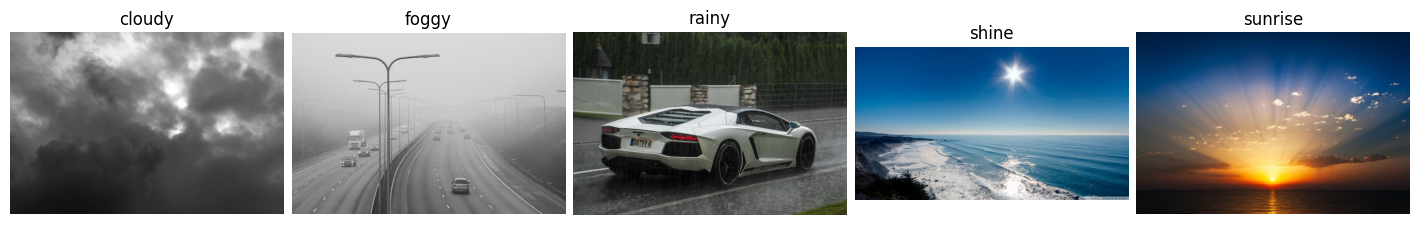

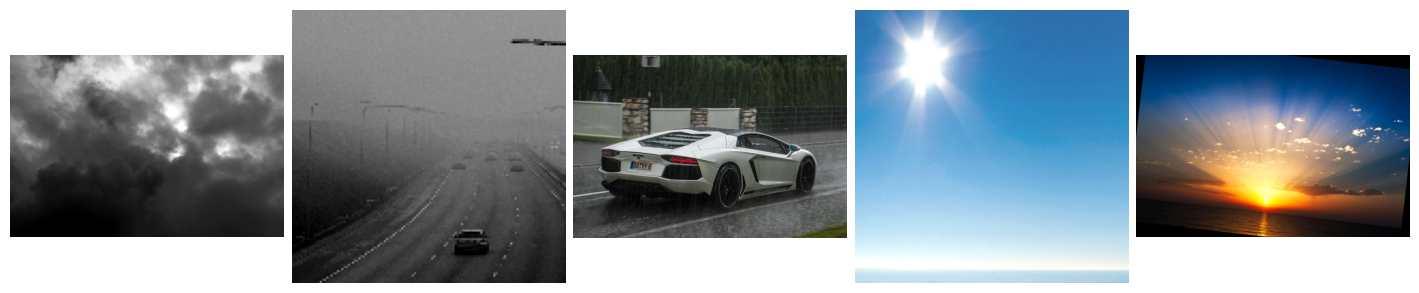

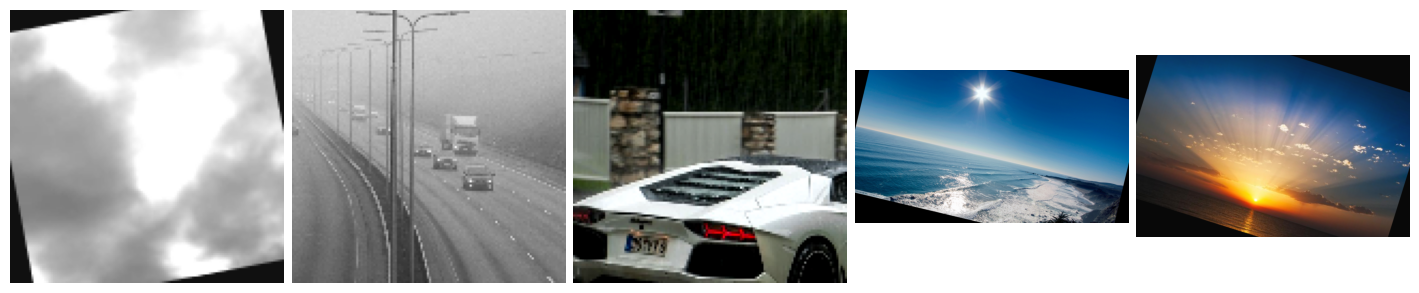

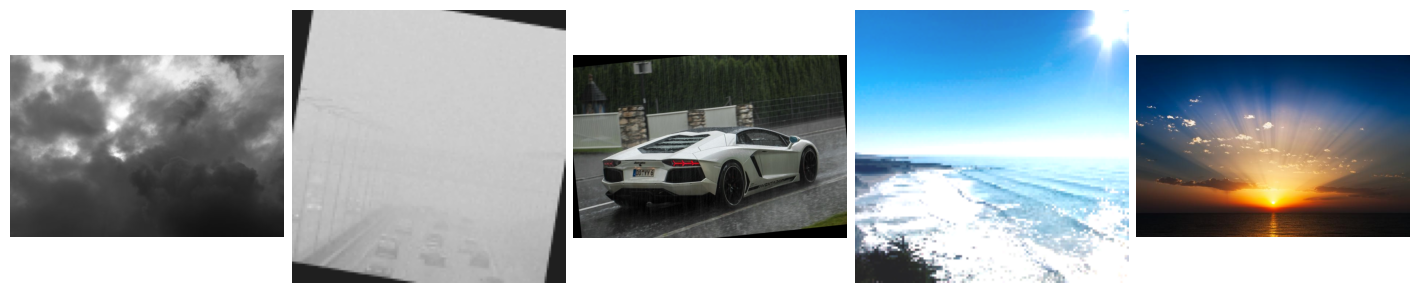

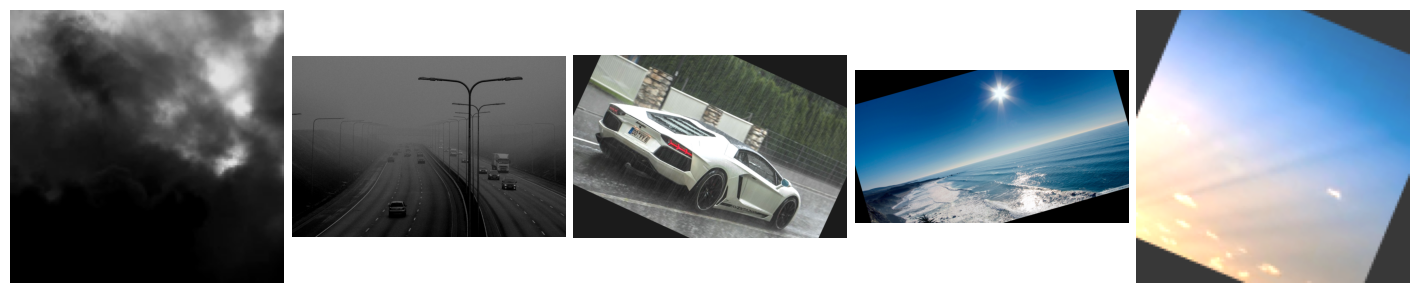

: 

: 

: 

: 

: 

: 

: 

: 

In [ ]:
show_images(weather_images, titles)
for _ in range(4):
    transformed = [
        MyTransform(image=np.array(image))["image"]
        for image in weather_images
        #
    ]
    show_images(transformed)

In [ ]:
MyTransform = A.Compose(
    [
        A.SmallestMaxSize(max_size=160),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.RandomCrop(height=128, width=128),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
        A.HorizontalFlip(p=0.3),
    ]
)

c:\coding\falt_lessons\MIPT_ML_CV\_venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


: 

: 

: 

: 

: 

: 

: 

: 

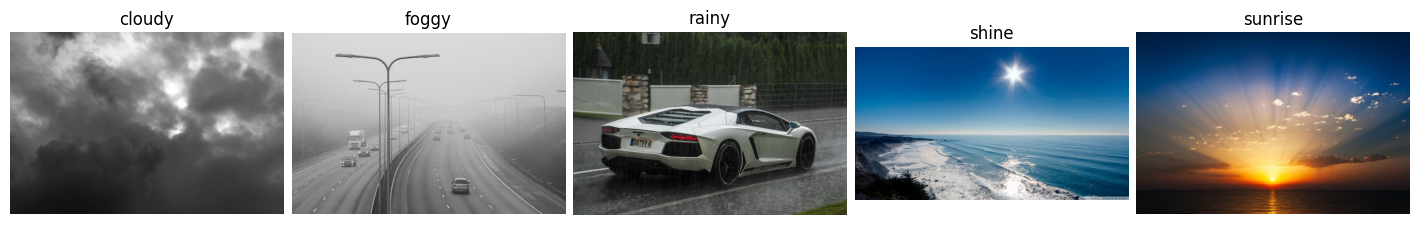

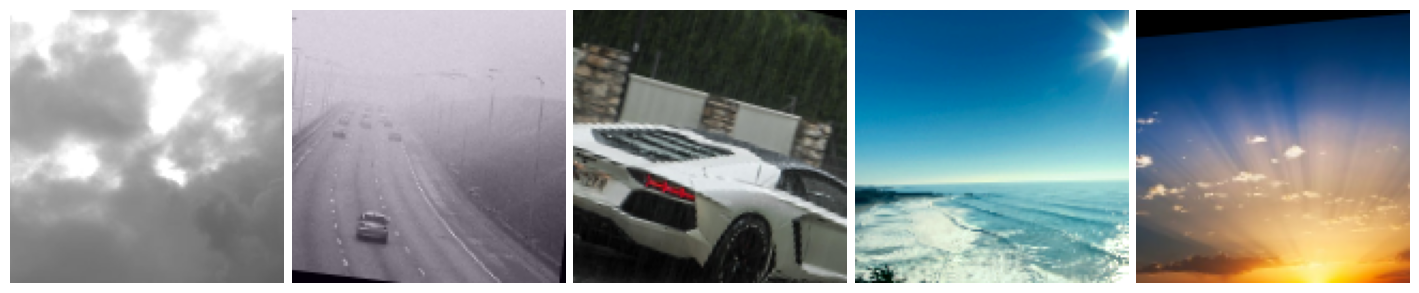

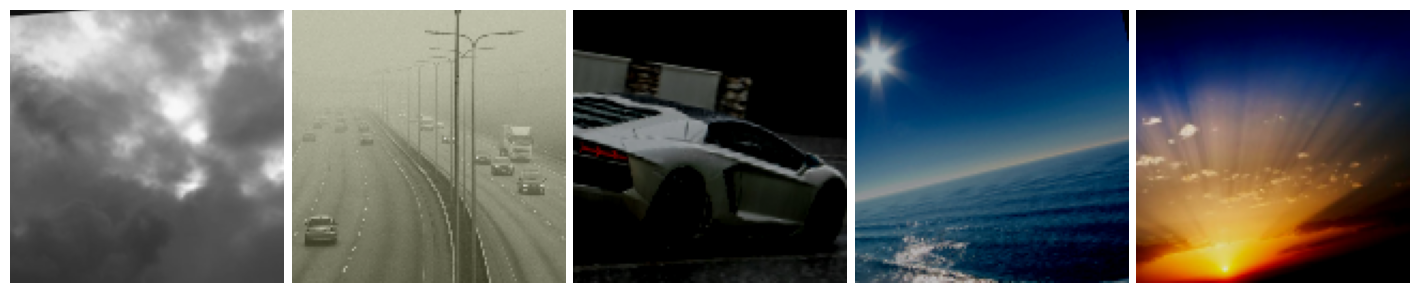

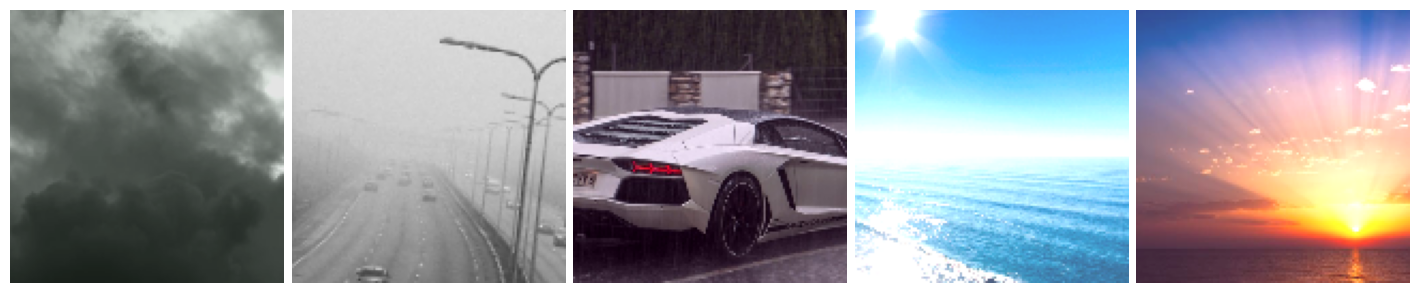

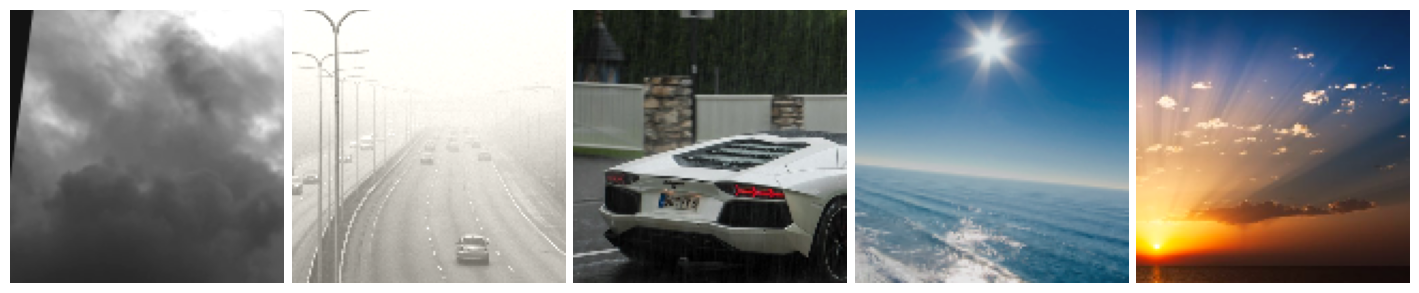

: 

: 

: 

: 

: 

: 

: 

: 

In [ ]:
show_images(weather_images, titles)
for _ in range(4):
    transformed = [
        MyTransform(image=np.array(image))["image"]
        for image in weather_images
        #
    ]
    show_images(transformed)

#### Ковариантное преобразование изображений и меток

![](https://code.mipt.ru/courses-public/cv/storage/-/raw/seminars/nn-training-basics/albumentations_2.png)

------

### Добавим аугментации в обучение

In [ ]:
import albumentations.pytorch.transforms

augmentations = [
    A.SmallestMaxSize(max_size=160),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.RandomCrop(height=128, width=128),
    A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.HorizontalFlip(p=0.3),
]
# Don't forget to prepare the image data for consumption by PyTorch
common_transforms = [
    A.Resize(*NETWORK_SIZE),
    A.ToFloat(max_value=255),
    A.Normalize(max_pixel_value=1.0, mean=IMAGENET_MEAN, std=IMAGENET_STD),
    A.pytorch.transforms.ToTensorV2(),
]

MyTrainTransform = A.Compose(augmentations + common_transforms)
MyValidTransform = A.Compose(common_transforms)

: 

: 

: 

: 

: 

: 

: 

: 

In [ ]:
def my_train_transform(image):
    return MyTrainTransform(image=image)["image"]


def my_valid_transform(image):
    return MyValidTransform(image=image)["image"]


ds_train_alb = MyCustomDataset(
    mode="train",
    transform=my_train_transform,
)
ds_valid_alb = MyCustomDataset(
    mode="valid",
    transform=my_valid_transform,
)

dl_train_alb = data.DataLoader(
    ds_train_alb,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)
dl_valid_alb = data.DataLoader(
    ds_valid_alb,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

: 

: 

: 

: 

: 

: 

: 

: 

In [ ]:
training_module = MyTrainingModule_WithLRScheduler()
trainer = L.Trainer(
    max_epochs=100,
    accelerator="auto",
    callbacks=[
        my_progress_bar(),
        my_lr_monitor(),
        my_training_checkpoint(),
        my_early_stopping(),
    ],
    log_every_n_steps=1,  # for demonstration puproses only
)
trainer.fit(training_module, dl_train_alb, dl_valid_alb)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ MyModel            │ 42.2 K │ train │     0 │
│ 1 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 42.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 42.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

: 

: 

: 

: 

: 

---